# Cost function study

In [1]:
import numpy as np
import healpy as hp
import matplotlib.pyplot as plt
%matplotlib inline
import astropy.units as u
from astropy.coordinates import SkyCoord
#import pyccl as ccl

from simulMap import *
from lumMag_sampling import *
from cluster import *
from fitMap import *
from mappers import DepthMapper, CountMapper

In [2]:
#resolution:
nside = 64
npix = hp.nside2npix(nside)
print("Number of pixels = {}".format(npix))

#sources:
NSource_px_th = int(1e6)
print("Total number of sources in the entire sky : {}".format(NSource_px_th*npix))
print("Theorical number of sources in one pixel : {}".format(NSource_px_th))

Number of pixels = 49152
Total number of sources in the entire sky : 49152000000
Theorical number of sources in one pixel : 1000000


In [3]:
lb2raDec(264, 48)

(167.78661173067627, -7.145388724109016)

## Dipole creation

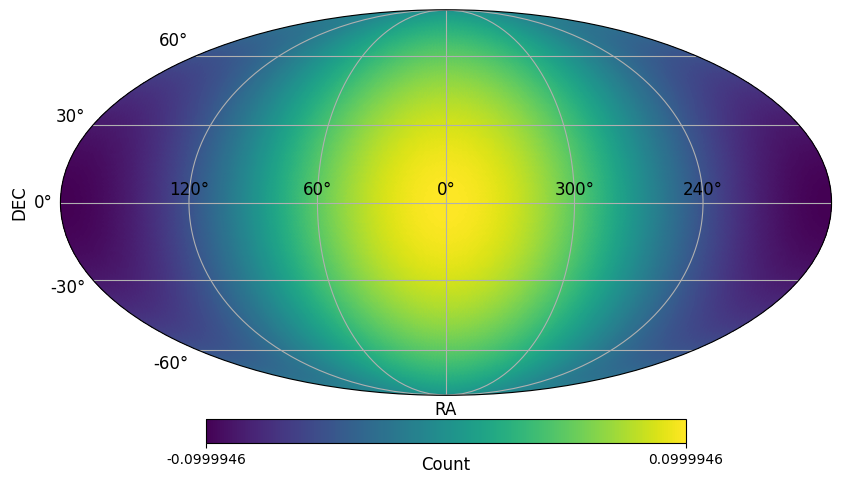

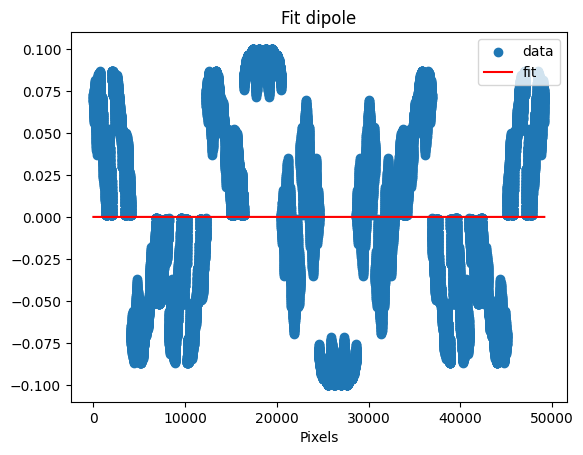

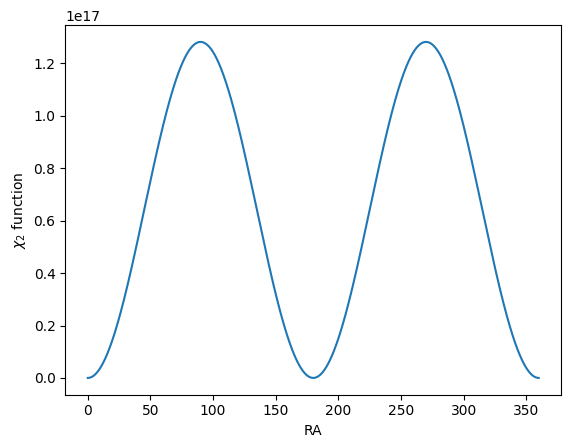

In [11]:
nest = True
A, l, b = 0.1, 0, 0
NSource_px_dipole = apply_dipole_Alb(np.arange(npix), A, l, b, nest)
dipoleMapper = CountMapper.from_map(NSource_px_dipole, nest=nest)

init =  (0, 100, 40)
m, cost = dipoleMapper.fit_dipole("", init, get_cost=True, fit_monop=False)

param = (A, l, b)
ls, fig, ax = get_LeastSquare_plot(cost, param, stop=360, xlabel="RA", get_fig=True, label = f"RA_true = {l} ; DEC_true = {b}")

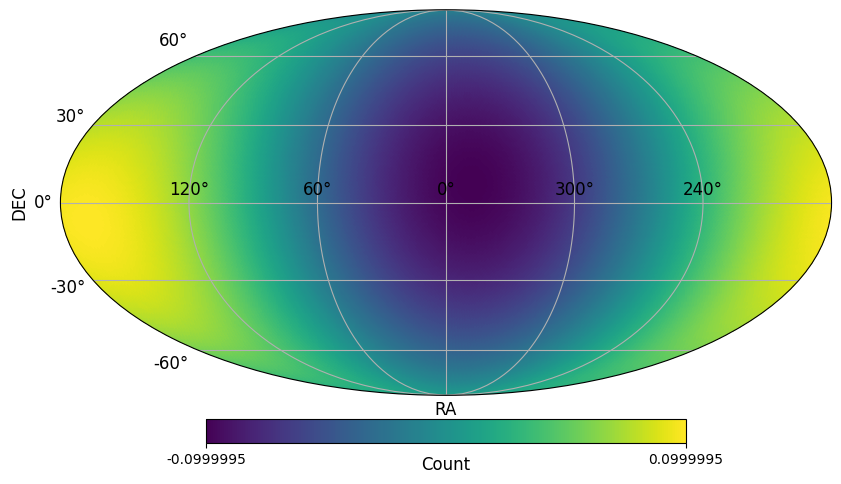

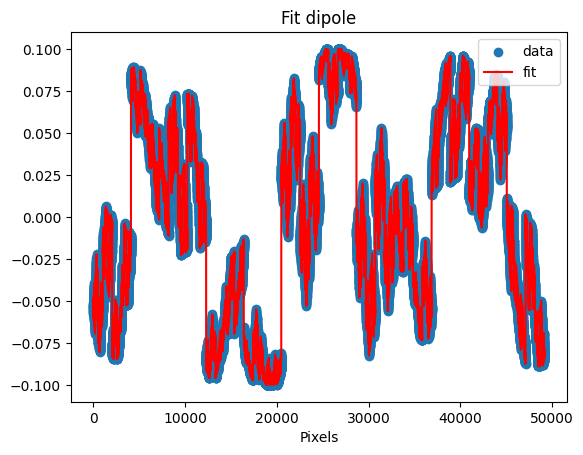

In [12]:
A, l, b = 0.1, 167, -7
NSource_px_dipole = apply_dipole_Alb(np.arange(npix), A, l, b, nest)
dipoleMapper = CountMapper.from_map(NSource_px_dipole, nest=nest)
m, cost = dipoleMapper.fit_dipole("", init, get_cost=True, fit_monop=False)

param = (A, l, b)
ls2, fig, ax = get_LeastSquare_plot(cost, param, stop=360, xlabel="RA", get_fig=True, label = f"RA_true = {l} ; DEC_true = {b}")

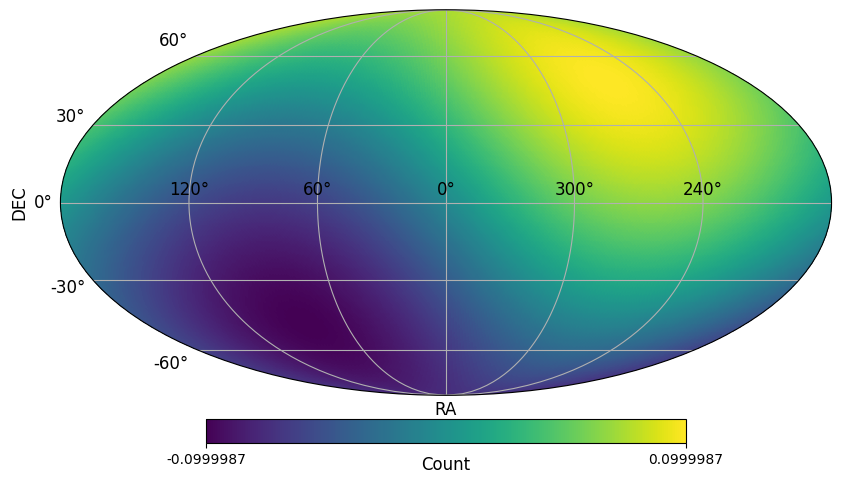

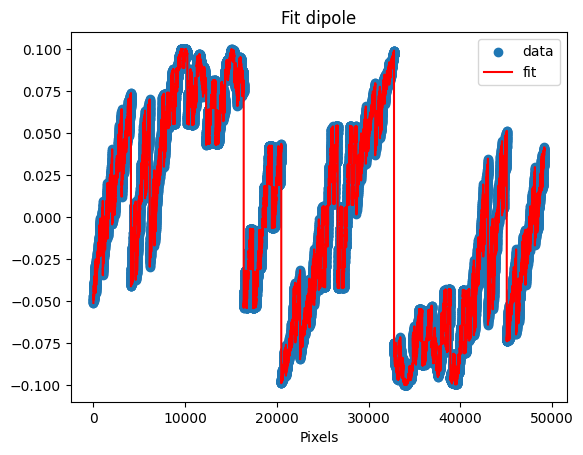

In [13]:
A, l, b = 0.1, 264, 48
NSource_px_dipole = apply_dipole_Alb(np.arange(npix), A, l, b, nest)
dipoleMapper = CountMapper.from_map(NSource_px_dipole, nest=nest)
m, cost = dipoleMapper.fit_dipole("", init, get_cost=True, fit_monop=False)

param = (A, l, b)
ls3, fig, ax = get_LeastSquare_plot(cost, param, stop=360, xlabel="RA", get_fig=True, label = f"RA_true = {l} ; DEC_true = {b}")

Saving chi2_vs_paramRA_Compare in Simul_Figures/Simul_Dip/Dip_NoMonop_chi2_vs_paramRA_Compare.pdf


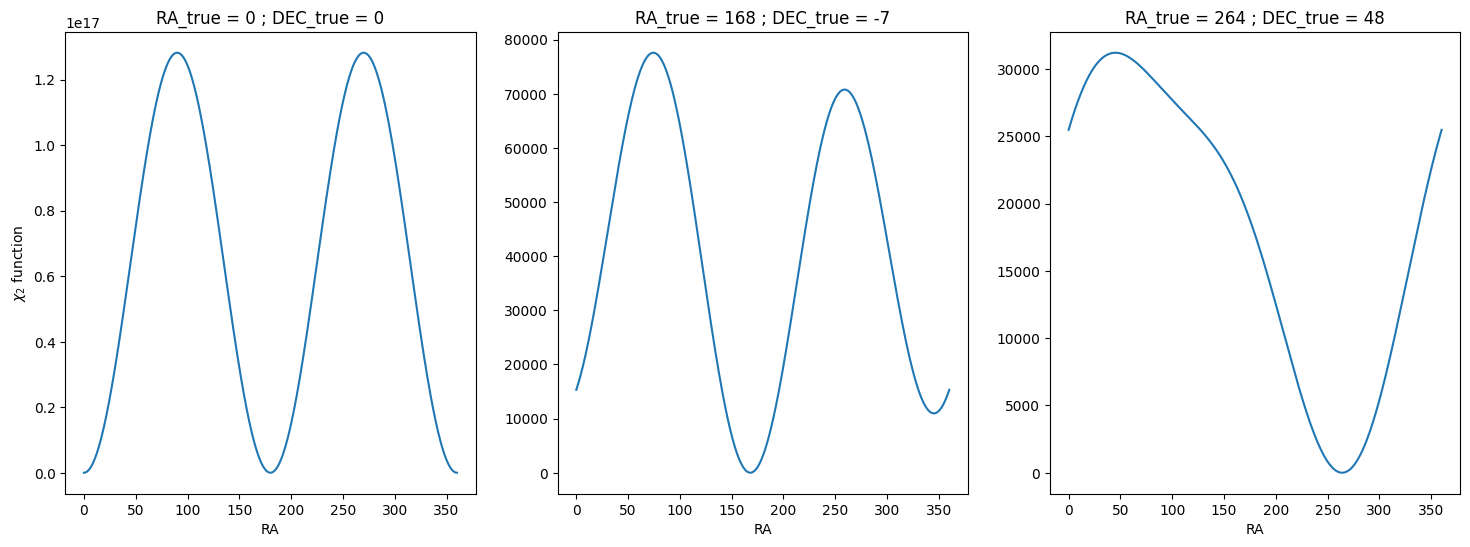

In [10]:
fig, ax = plt.subplots(1, 3, figsize=(18, 6))
RA_x = np.linspace(0, 360, 10000)
ax[0].plot(RA_x, ls)
ax[0].set_title(f"RA_true = {0} ; DEC_true = {0}")
ax[0].set_xlabel('RA')
ax[0].set_ylabel("$\chi_2$ function")

ax[1].plot(RA_x, ls2)
ax[1].set_title(f"RA_true = {168} ; DEC_true = {-7}")
ax[1].set_xlabel('RA')

ax[2].plot(RA_x, ls3)
ax[2].set_title(f"RA_true = {264} ; DEC_true = {48}")
ax[2].set_xlabel('RA')

output_path = "Simul_Figures/Simul_Dip/Dip_NoMonop_"
get_savefig(fig=fig, output_path=output_path, sufix="chi2_vs_paramRA_Compare")

## Monopole creation

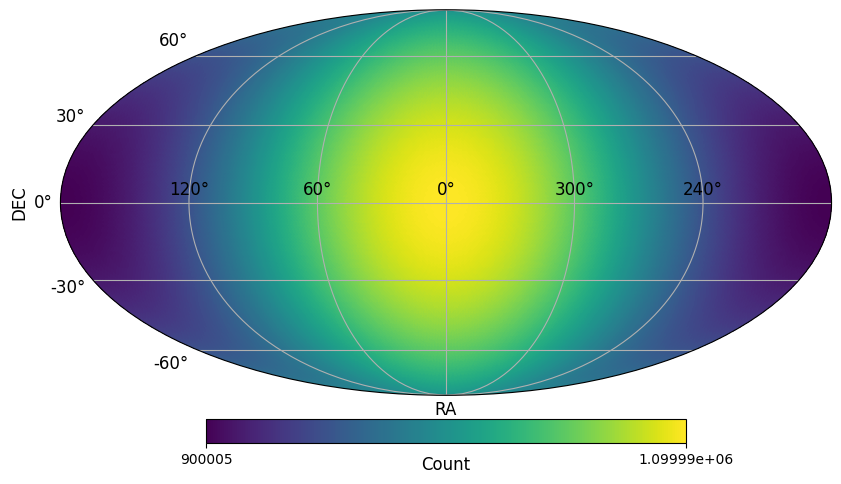

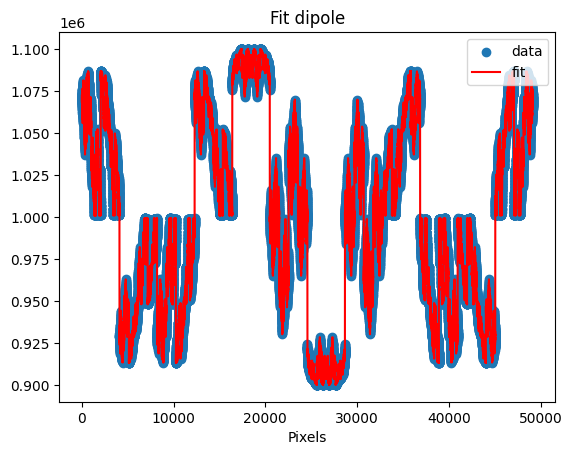

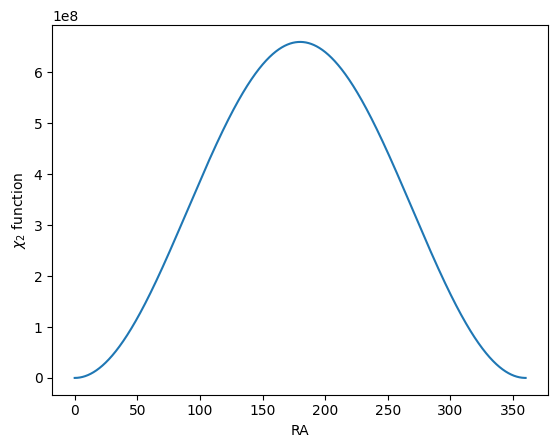

In [14]:
A, l, b = 0.1, 0, 0
NSource_px_dipole = apply_dipole_Alb(np.arange(npix), A, l, b, nest)
NSource_px_dipole_lb = NSource_px_th*(1 + NSource_px_dipole)
monopMapper = CountMapper.from_map(NSource_px_dipole_lb, nest=nest)

init =  (1e5, 0, 100, 40)
m, cost = monopMapper.fit_dipole("", init, get_cost=True)

param = (NSource_px_th, A, l, b)
ls = get_LeastSquare_plot(cost, param, stop=360, xlabel="RA")

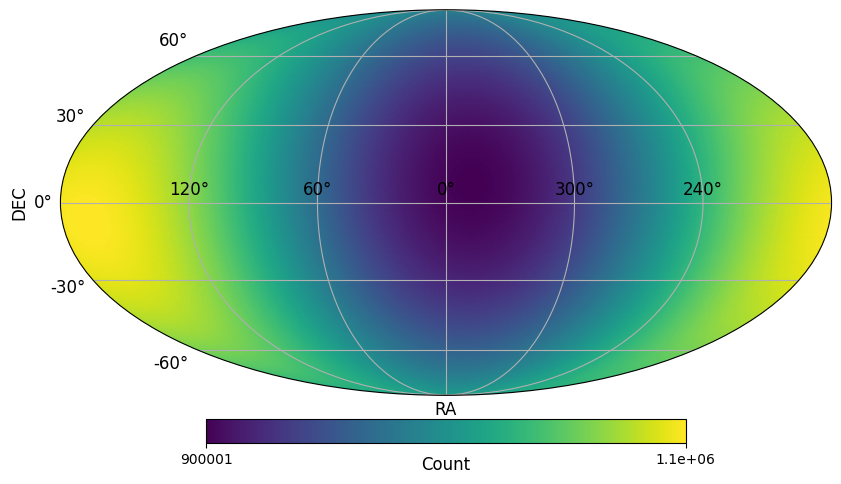

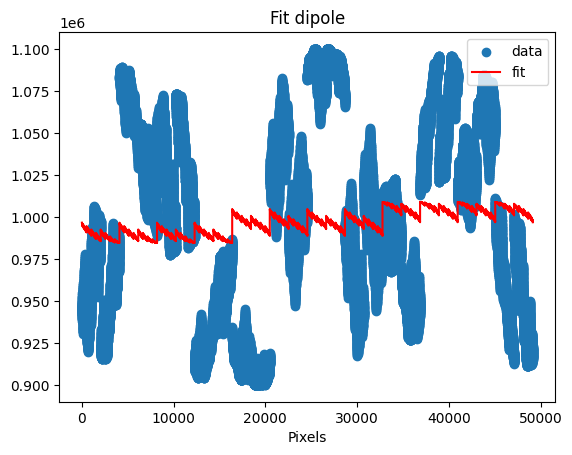

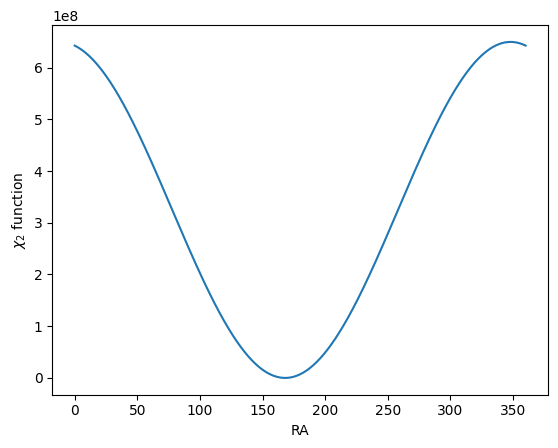

In [15]:
A, l, b = 0.1, 168, -7
NSource_px_dipole = apply_dipole_Alb(np.arange(npix), A, l, b, nest)
NSource_px_dipole_lb = NSource_px_th*(1 + NSource_px_dipole)
monopMapper = CountMapper.from_map(NSource_px_dipole_lb, nest=nest)

init =  (1e5, 0, 100, 40)
m, cost = monopMapper.fit_dipole("", init, get_cost=True)

param = (NSource_px_th, A, l, b)
ls2 = get_LeastSquare_plot(cost, param, stop=360, xlabel="RA")

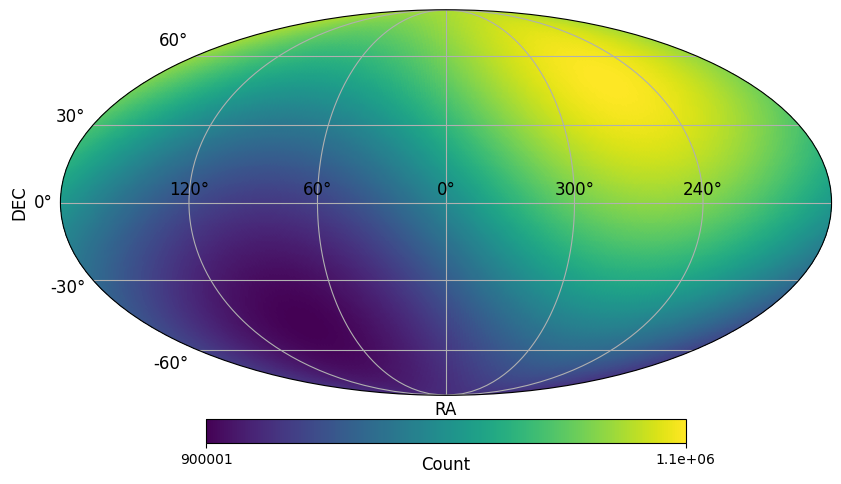

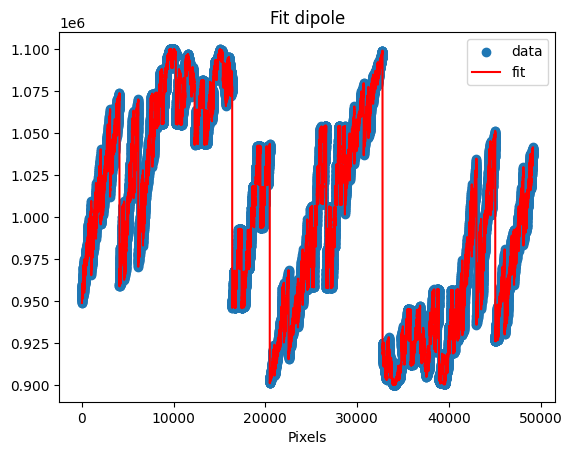

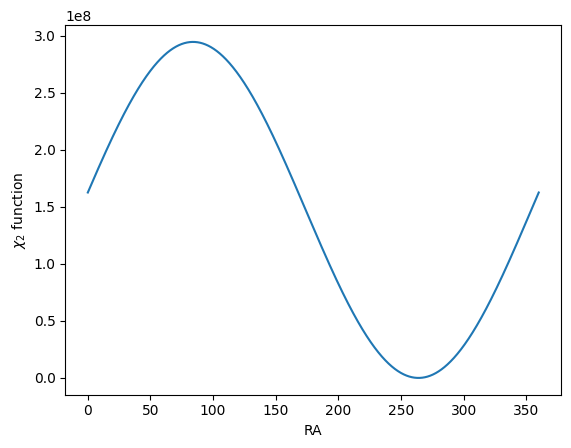

In [16]:
A, l, b = 0.1, 264, 48
NSource_px_dipole = apply_dipole_Alb(np.arange(npix), A, l, b, nest)
NSource_px_dipole_lb = NSource_px_th*(1 + NSource_px_dipole)
monopMapper = CountMapper.from_map(NSource_px_dipole_lb, nest=nest)

init =  (1e5, 0, 100, 40)
m, cost = monopMapper.fit_dipole("", init, get_cost=True)

param = (NSource_px_th, A, l, b)
ls3 = get_LeastSquare_plot(cost, param, stop=360, xlabel="RA")

Saving chi2_vs_paramRA_Compare in Simul_Figures/Simul_Monop/Monopp_NoVar_chi2_vs_paramRA_Compare.pdf


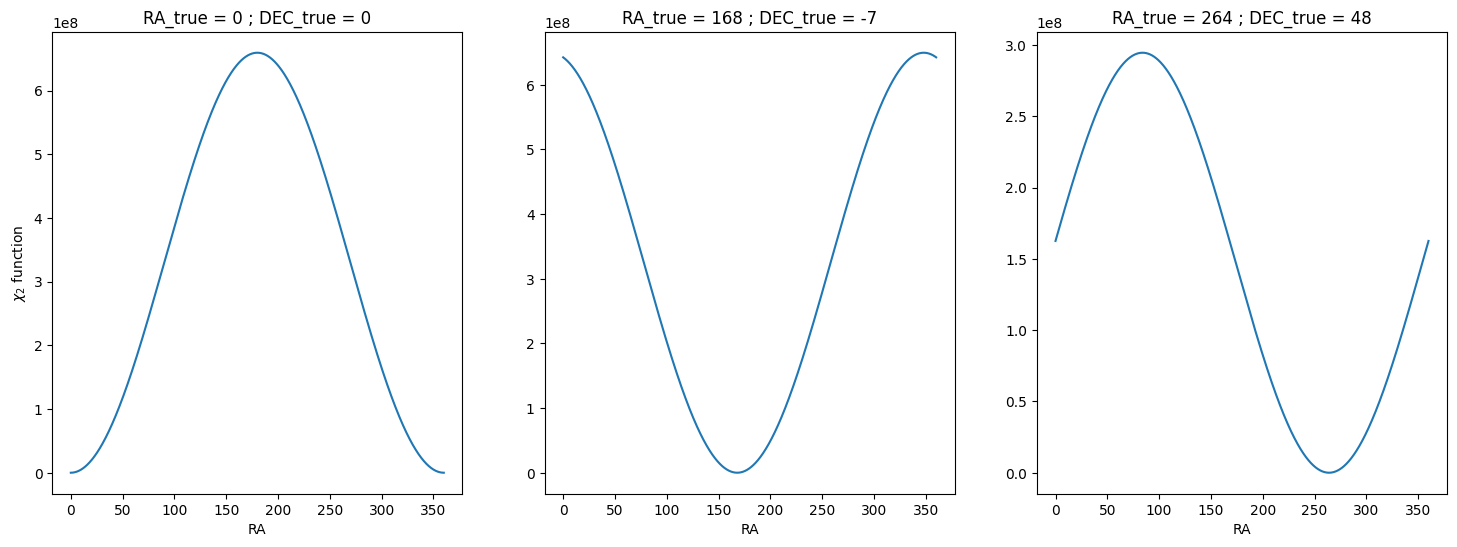

In [17]:
fig, ax = plt.subplots(1, 3, figsize=(18, 6))
RA_x = np.linspace(0, 360, 10000)
ax[0].plot(RA_x, ls)
ax[0].set_title(f"RA_true = {0} ; DEC_true = {0}")
ax[0].set_xlabel('RA')
ax[0].set_ylabel("$\chi_2$ function")

ax[1].plot(RA_x, ls2)
ax[1].set_title(f"RA_true = {168} ; DEC_true = {-7}")
ax[1].set_xlabel('RA')

ax[2].plot(RA_x, ls3)
ax[2].set_title(f"RA_true = {264} ; DEC_true = {48}")
ax[2].set_xlabel('RA')

output_path = "Simul_Figures/Simul_Monop/Monopp_NoVar_"
get_savefig(fig=fig, output_path=output_path, sufix="chi2_vs_paramRA_Compare")